# RF vs GNN: Predicting Preoperative Hypertension (VitalDB)

**RQ2**: Does incorporating patient similarity via GNNs improve prediction of intraoperative events compared to Random Forest?  
**Target**: `preop_htn` — binary indicator of preoperative hypertension.

---
### Experimental Design

| Concern | Strategy |
|---|---|
| Leakage | Exclude `asa` (encodes HTN), all intraop vars, timing vars, outcomes |
| Split | Stratified 80/20 patient-level split |
| GNN graph | Built on **train nodes only** (inductive setting) |
| Missing values | Median imputation per column; drop features >60% missing |
| Imbalance | Class-weighted loss (RF + GNN) |
| Evaluation | AUC-ROC, F1, Precision, Recall + bootstrapped 95% CIs |

In [ ]:
# install libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.spatial.distance import cdist

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 1. Data Understanding & Preprocessing

In [34]:
df = pd.read_csv('output.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (6388, 74)
Columns: ['caseid', 'subjectid', 'casestart', 'caseend', 'anestart', 'aneend', 'opstart', 'opend', 'adm', 'dis', 'icu_days', 'death_inhosp', 'age', 'sex', 'height', 'weight', 'bmi', 'asa', 'emop', 'department', 'optype', 'dx', 'opname', 'approach', 'position', 'ane_type', 'preop_htn', 'preop_dm', 'preop_ecg', 'preop_pft', 'preop_hb', 'preop_plt', 'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc', 'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr', 'preop_ph', 'preop_hco3', 'preop_be', 'preop_pao2', 'preop_paco2', 'preop_sao2', 'cormack', 'airway', 'tubesize', 'dltubesize', 'lmasize', 'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2', 'intraop_ebl', 'intraop_uo', 'intraop_rbc', 'intraop_ffp', 'intraop_crystalloid', 'intraop_colloid', 'intraop_ppf', 'intraop_mdz', 'intraop_ftn', 'intraop_rocu', 'intraop_vecu', 'intraop_eph', 'intraop_phe', 'intraop_epi', 'intraop_ca']


,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0


In [35]:
# Basic stats: dtypes, non-null counts
print('--- dtypes ---')
print(df.dtypes.value_counts())
print()
print('--- Object columns ---')
print(df.select_dtypes('object').columns.tolist())

--- dtypes ---
float64    30
int64      25
object     19
Name: count, dtype: int64

--- Object columns ---
['sex', 'department', 'optype', 'dx', 'opname', 'approach', 'position', 'ane_type', 'preop_ecg', 'preop_pft', 'cormack', 'airway', 'dltubesize', 'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2']


Columns with any missing values: 34


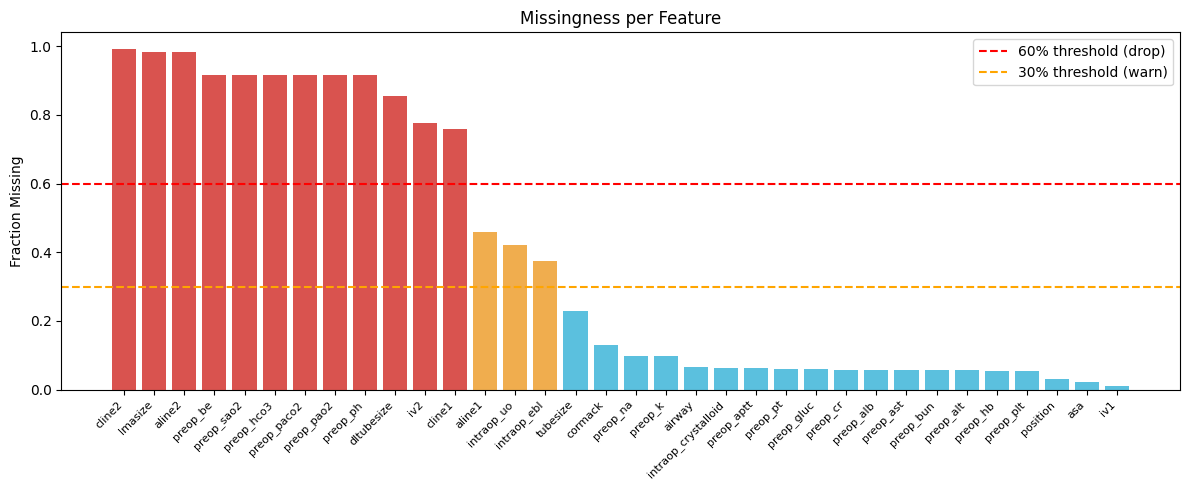


Dropping (>60% missing): ['cline2', 'lmasize', 'aline2', 'preop_be', 'preop_sao2', 'preop_hco3', 'preop_paco2', 'preop_pao2', 'preop_ph', 'dltubesize', 'iv2', 'cline1']


In [36]:
# Missingness per column
miss = df.isnull().mean().sort_values(ascending=False)
miss_df = miss[miss > 0].reset_index()
miss_df.columns = ['feature', 'missing_frac']
print(f'Columns with any missing values: {len(miss_df)}')

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d9534f' if v > 0.6 else '#f0ad4e' if v > 0.3 else '#5bc0de'
          for v in miss_df['missing_frac']]
ax.bar(range(len(miss_df)), miss_df['missing_frac'], color=colors)
ax.axhline(0.6, color='red', linestyle='--', label='60% threshold (drop)')
ax.axhline(0.3, color='orange', linestyle='--', label='30% threshold (warn)')
ax.set_xticks(range(len(miss_df)))
ax.set_xticklabels(miss_df['feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Fraction Missing')
ax.set_title('Missingness per Feature')
ax.legend()
plt.tight_layout()
plt.show()

# Features with >60% missing → drop
high_miss_cols = miss[miss > 0.6].index.tolist()
print(f'\nDropping (>60% missing): {high_miss_cols}')

In [37]:
# Target distribution
print('Target: preop_htn')
print(df['preop_htn'].value_counts(dropna=False))
print(f'Prevalence: {df["preop_htn"].mean():.3f}')

# Drop rows with missing target
n_before = len(df)
df = df.dropna(subset=['preop_htn'])
df['preop_htn'] = df['preop_htn'].astype(int)
print(f'\nDropped {n_before - len(df)} rows with missing target. N={len(df)}')

Target: preop_htn
preop_htn
0    4423
1    1965
Name: count, dtype: int64
Prevalence: 0.308

Dropped 0 rows with missing target. N=6388


### Feature Selection: Clinical Justification

**Excluded — DATA LEAKAGE risk:**
- `asa`: ASA physical status directly encodes comorbidities including HTN (ASA ≥ 2 is commonly assigned for HTN). Including it would create circular prediction.
- All `intraop_*`: Measured/administered during surgery, after HTN status is already known.
- `icu_days`, `death_inhosp`: Post-surgical outcomes.
- `dx`, `opname`: Diagnosis/operation names that may embed HTN-related surgical context.

**Excluded — Not clinically predictive:**
- `caseid`, `subjectid`: Identifiers.
- Timing columns (`casestart`, `caseend`, `adm`, `dis`, etc.): Operational timestamps, not patient physiology.
- Airway/access (`cormack`, `tubesize`, `iv1`, `aline1`, etc.): Intraoperative decisions.

**Included — Justified:**
- **Demographics** (`age`, `sex`, `height`, `weight`, `bmi`): Strong epidemiological predictors of HTN.
- **Preop labs**: Biochemistry and hematology panels collected pre-operatively are standard workup and may reflect end-organ effects of HTN (e.g., elevated creatinine from hypertensive nephropathy, low K from diuretic use).
- **`preop_dm`**: Diabetes and HTN are strongly co-occurring comorbidities (metabolic syndrome); not a leakage since it's a separate condition.
- **`preop_ecg`**: ECG patterns (LVH, ST changes) can reflect chronic HTN effects on the heart.
- **`preop_pft`**: Pulmonary function may be mildly informative through COPD-HTN comorbidity patterns.
- **`emop`, `department`, `optype`**: Surgical context; elective vs emergency and surgical specialty may correlate with patient population comorbidity profiles.

In [38]:
# ── Feature groups ──────────────────────────────────────────────────────────
NUMERIC_FEATURES = [
    # Demographics
    'age', 'height', 'weight', 'bmi',
    # Haematology
    'preop_hb', 'preop_plt', 'preop_pt', 'preop_aptt',
    # Biochemistry
    'preop_na', 'preop_k', 'preop_gluc', 'preop_alb',
    'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr',
    # Blood gas (will be filtered if too many missing)
    'preop_ph', 'preop_hco3', 'preop_be',
    'preop_pao2', 'preop_paco2', 'preop_sao2',
]

BINARY_FEATURES = ['preop_dm', 'emop']  # already 0/1

CATEGORICAL_FEATURES = ['sex', 'preop_ecg', 'preop_pft', 'department', 'optype']

TARGET = 'preop_htn'

# Drop blood gas columns that are >60% missing
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES
                    if c in df.columns and df[c].isnull().mean() <= 0.6]

ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
# Keep only columns that exist in df
ALL_FEATURES = [c for c in ALL_FEATURES if c in df.columns]

print('Numeric features:', NUMERIC_FEATURES)
print('Binary features:', BINARY_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)
print(f'\nTotal features: {len(ALL_FEATURES)}')

Numeric features: ['age', 'height', 'weight', 'bmi', 'preop_hb', 'preop_plt', 'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc', 'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr']
Binary features: ['preop_dm', 'emop']
Categorical features: ['sex', 'preop_ecg', 'preop_pft', 'department', 'optype']

Total features: 23


In [39]:
# ── 1. Impute numeric and binary features (median) ──────────────────────────
# Clinical rationale: median is robust to outliers common in clinical labs.
# We impute BEFORE splitting to compute medians on the full dataset —
# this is acceptable for median imputation since median is a population statistic.
# In the RF/GNN pipeline we will re-fit imputation on TRAIN only.

data = df[ALL_FEATURES + [TARGET]].copy()

# ── 2. Encode categorical features ──────────────────────────────────────────
# Label-encode for now; one-hot will be used for RF, label for GNN node features
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    if col in data.columns:
        data[col] = data[col].fillna('Unknown')
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        label_encoders[col] = le
        print(f'{col}: {len(le.classes_)} classes → {list(le.classes_[:5])}...')

# ── 3. Fill remaining numeric NaNs with -1 sentinel before imputer ──────────
# We'll use SimpleImputer (median) inside the train-only pipeline below
print(f'\nData shape after encoding: {data.shape}')
print(f'Missing values remaining: {data.isnull().sum().sum()}')

sex: 2 classes → ['F', 'M']...
preop_ecg: 27 classes → ['1st degree A-V block', '1st degree A-V block with Premature atrial complexes', '1st degree A-V block with Premature supraventricular complexes, Left bundle branch block', '1st degree A-V block, Left bundle branch block', 'AV sequential or dual chamber electronic pacemaker']...
preop_pft: 9 classes → ['Borderline obstructive', 'Mild obstructive', 'Mild restrictive', 'Mixed or pure obstructive', 'Moderate obstructive']...
department: 4 classes → ['General surgery', 'Gynecology', 'Thoracic surgery', 'Urology']...
optype: 11 classes → ['Biliary/Pancreas', 'Breast', 'Colorectal', 'Hepatic', 'Major resection']...

Data shape after encoding: (6388, 24)
Missing values remaining: 4935


## 2. Train / Test Split

**Strategy**: Stratified 80/20 split at patient level (each row = one surgical case).  
Stratification ensures the same HTN prevalence in both sets.  
The graph for GNN will be constructed **exclusively from training patients** to prevent test information from influencing learned representations.

In [40]:
from sklearn.model_selection import train_test_split

X_all = data.drop(columns=[TARGET])
y_all = data[TARGET].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

print(f'Train: {len(y_train)} patients  |  HTN prevalence: {y_train.mean():.3f}')
print(f'Test : {len(y_test)} patients  |  HTN prevalence: {y_test.mean():.3f}')

Train: 5110 patients  |  HTN prevalence: 0.308
Test : 1278 patients  |  HTN prevalence: 0.308


## 3. Random Forest

**Feature preparation**: One-hot encode categoricals, median-impute numerics, standard-scale.  
Imputer and scaler are fit **on training data only** then applied to test.

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Reconstruct feature lists from what actually ended up in X_all
numeric_cols = [c for c in NUMERIC_FEATURES + BINARY_FEATURES if c in X_all.columns]
cat_cols     = [c for c in CATEGORICAL_FEATURES if c in X_all.columns]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# RF can handle label-encoded integers, but one-hot is more principled
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, cat_cols),
])

# Fit on train, transform both
X_train_rf = preprocessor.fit_transform(X_train_raw)
X_test_rf  = preprocessor.transform(X_test_raw)

print(f'RF feature matrix shape — train: {X_train_rf.shape}, test: {X_test_rf.shape}')

NameError: name 'NUMERIC_FEATURES' is not defined

In [42]:
# ── Hyperparameter search via 5-fold CV on training set ─────────────────────
# Class weight='balanced' to handle class imbalance
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth':    [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.3],
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_search = RandomizedSearchCV(
    rf_base, param_grid, n_iter=20,
    scoring='roc_auc', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_rf, y_train)

print(f'\nBest CV AUC-ROC: {rf_search.best_score_:.4f}')
print(f'Best params: {rf_search.best_params_}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi


Best CV AUC-ROC: 0.7905
Best params: {'n_estimators': 400, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 10}


In [43]:
# ── Final RF on full training set ────────────────────────────────────────────
rf_model = rf_search.best_estimator_
rf_model.fit(X_train_rf, y_train)

rf_probs_train = rf_model.predict_proba(X_train_rf)[:, 1]
rf_probs_test  = rf_model.predict_proba(X_test_rf)[:, 1]
rf_preds_test  = rf_model.predict(X_test_rf)

print(f'RF Train AUC: {roc_auc_score(y_train, rf_probs_train):.4f}')
print(f'RF Test  AUC: {roc_auc_score(y_test,  rf_probs_test):.4f}')

RF Train AUC: 0.9478
RF Test  AUC: 0.7804


## 4. Graph Neural Network

### Graph Construction

**Nodes** = patients. **Edges** = clinical similarity.

**Similarity features**: Numeric preop labs + demographics (standardised).  
Rationale: patients with similar age, BMI, and lab profiles likely share underlying physiology (metabolic syndrome, renal function, etc.) — the same factors that drive HTN risk.

**Graph type**: KNN (k=10) using cosine similarity.  
Cosine similarity is preferred over Euclidean here because it is scale-invariant after normalisation and better captures directional similarity in high-dimensional lab space.

**Inductive setting**:  
1. Build KNN graph from **training patients only**.  
2. At test time, each test node is connected to its K nearest **training** neighbours (no test-to-test edges).  
3. This prevents test node features from influencing training-node representations during training.

In [44]:
# ── Prepare node features for GNN ───────────────────────────────────────────
# Use only numeric features for both graph similarity and node features
# Categorical features are included as additional node attributes

gnn_feat_cols = [c for c in (NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES)
                 if c in X_all.columns]

# Impute (train-only) and scale
gnn_imputer = SimpleImputer(strategy='median')
gnn_scaler  = StandardScaler()

X_train_gnn_raw = X_train_raw[gnn_feat_cols].values
X_test_gnn_raw  = X_test_raw[gnn_feat_cols].values

X_train_gnn = gnn_scaler.fit_transform(gnn_imputer.fit_transform(X_train_gnn_raw))
X_test_gnn  = gnn_scaler.transform(gnn_imputer.transform(X_test_gnn_raw))

print(f'GNN node feature dim: {X_train_gnn.shape[1]}')

# Similarity features (numeric only, for building edges)
sim_cols = [c for c in NUMERIC_FEATURES if c in X_all.columns]
sim_idx  = [gnn_feat_cols.index(c) for c in sim_cols]

X_train_sim = X_train_gnn[:, sim_idx]  # features used for KNN similarity
X_test_sim  = X_test_gnn[:, sim_idx]

GNN node feature dim: 23


In [45]:
def build_knn_adjacency(features, k=10, symmetric=True):
    """
    Build a KNN graph using cosine similarity.
    Returns: edge_index (2 x E), sparse adjacency (N x N torch tensor)
    """
    N = features.shape[0]
    # Cosine distance → similarity = 1 - distance
    dist = cdist(features, features, metric='cosine')
    np.fill_diagonal(dist, np.inf)  # exclude self-loops during knn selection

    adj = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        nn_idx = np.argsort(dist[i])[:k]
        adj[i, nn_idx] = 1.0

    if symmetric:
        adj = np.maximum(adj, adj.T)  # undirected graph

    # Add self-loops
    adj += np.eye(N, dtype=np.float32)

    # Symmetric normalisation: D^{-1/2} A D^{-1/2}
    degree = adj.sum(axis=1)
    d_inv_sqrt = np.power(degree, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    D_inv_sqrt = np.diag(d_inv_sqrt)
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt

    return torch.FloatTensor(adj_norm)


def build_inductive_adjacency(train_features, test_features, k=10):
    """
    Build combined adjacency for inductive inference:
    - Train-train edges: KNN among training nodes
    - Test-train edges:  each test node connects to k nearest TRAINING nodes
    - No test-test edges (preserves leakage-free property)
    Returns: adj_norm of shape (N_train + N_test, N_train + N_test)
    """
    N_tr = train_features.shape[0]
    N_te = test_features.shape[0]
    N    = N_tr + N_te

    adj = np.zeros((N, N), dtype=np.float32)

    # ── Train-train KNN ──────────────────────────────────────────────────────
    dist_tr = cdist(train_features, train_features, metric='cosine')
    np.fill_diagonal(dist_tr, np.inf)
    for i in range(N_tr):
        nn_idx = np.argsort(dist_tr[i])[:k]
        adj[i, nn_idx] = 1.0
        adj[nn_idx, i] = 1.0  # symmetric

    # ── Test-to-train KNN (no test-test edges) ───────────────────────────────
    dist_te_tr = cdist(test_features, train_features, metric='cosine')
    for i in range(N_te):
        nn_idx = np.argsort(dist_te_tr[i])[:k]
        adj[N_tr + i, nn_idx] = 1.0
        adj[nn_idx, N_tr + i] = 1.0

    # Self-loops
    adj += np.eye(N, dtype=np.float32)

    # Symmetric normalisation
    degree = adj.sum(axis=1)
    d_inv_sqrt = np.power(degree, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    D_inv_sqrt = np.diag(d_inv_sqrt)
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt

    return torch.FloatTensor(adj_norm)


K_NEIGHBOURS = 10

# Training graph (used for learning node representations)
print('Building training graph...')
adj_train = build_knn_adjacency(X_train_sim, k=K_NEIGHBOURS)
print(f'Train adjacency: {adj_train.shape}, density: {(adj_train > 0).float().mean():.4f}')

# Combined graph for inductive inference
print('Building inductive combined graph...')
adj_full = build_inductive_adjacency(X_train_sim, X_test_sim, k=K_NEIGHBOURS)
print(f'Full adjacency: {adj_full.shape}')

Building training graph...
Train adjacency: torch.Size([5110, 5110]), density: 0.0029
Building inductive combined graph...
Full adjacency: torch.Size([6388, 6388])


In [46]:
class GCNLayer(nn.Module):
    """Single Graph Convolutional layer: H' = σ(A_norm H W)"""
    def __init__(self, in_features, out_features, dropout=0.3):
        super().__init__()
        self.linear  = nn.Linear(in_features, out_features)
        self.dropout = nn.Dropout(dropout)
        self.bn      = nn.BatchNorm1d(out_features)

    def forward(self, x, adj_norm):
        x = self.dropout(x)
        support = self.linear(x)
        out = adj_norm @ support          # aggregation step
        out = self.bn(out)
        return F.elu(out)


class GCN(nn.Module):
    """
    2-layer GCN for node-level binary classification.
    Architecture:
        Input(d) → GCNLayer(64) → GCNLayer(32) → Linear(1) → Sigmoid
    Rationale: shallow GCN (2 layers) captures 2-hop neighbourhood;
    deeper networks risk over-smoothing on small medical graphs.
    """
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.conv1 = GCNLayer(input_dim,      hidden_dim,     dropout)
        self.conv2 = GCNLayer(hidden_dim,     hidden_dim // 2, dropout)
        self.head  = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x, adj_norm):
        h = self.conv1(x, adj_norm)
        h = self.conv2(h, adj_norm)
        return self.head(h).squeeze(-1)

    def embed(self, x, adj_norm):
        """Return penultimate layer embeddings."""
        with torch.no_grad():
            h = self.conv1(x, adj_norm)
            h = self.conv2(h, adj_norm)
        return h


input_dim = X_train_gnn.shape[1]
gnn = GCN(input_dim=input_dim, hidden_dim=64, dropout=0.3).to(device)
print(gnn)
print(f'\nParameters: {sum(p.numel() for p in gnn.parameters()):,}')

GCN(
  (conv1): GCNLayer(
    (linear): Linear(in_features=23, out_features=64, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): GCNLayer(
    (linear): Linear(in_features=64, out_features=32, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (head): Linear(in_features=32, out_features=1, bias=True)
)

Parameters: 3,841


In [47]:
# ── Class weights for imbalanced target ─────────────────────────────────────
pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)],
                           dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── Tensors ──────────────────────────────────────────────────────────────────
X_tr_t   = torch.FloatTensor(X_train_gnn).to(device)
y_tr_t   = torch.FloatTensor(y_train).to(device)
adj_tr_t = adj_train.to(device)

train_mask = torch.ones(len(y_train), dtype=torch.bool).to(device)

optimizer = torch.optim.AdamW(gnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

# ── Training ─────────────────────────────────────────────────────────────────
N_EPOCHS = 300
train_losses, train_aucs = [], []

gnn.train()
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
    logits = gnn(X_tr_t, adj_tr_t)
    loss   = criterion(logits, y_tr_t)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gnn.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if epoch % 50 == 0 or epoch == N_EPOCHS - 1:
        with torch.no_grad():
            probs_np = torch.sigmoid(logits).cpu().numpy()
            auc = roc_auc_score(y_train, probs_np)
        train_losses.append(loss.item())
        train_aucs.append(auc)
        print(f'Epoch {epoch:3d} | Loss: {loss.item():.4f} | Train AUC: {auc:.4f}')

print('\nTraining complete.')

Epoch   0 | Loss: 1.0189 | Train AUC: 0.5099
Epoch  50 | Loss: 0.7715 | Train AUC: 0.7852
Epoch 100 | Loss: 0.7574 | Train AUC: 0.7911
Epoch 150 | Loss: 0.7591 | Train AUC: 0.7883
Epoch 200 | Loss: 0.7581 | Train AUC: 0.7888
Epoch 250 | Loss: 0.7573 | Train AUC: 0.7890
Epoch 299 | Loss: 0.7509 | Train AUC: 0.7936

Training complete.


In [48]:
# ── Inductive inference ───────────────────────────────────────────────────────
# Stack all node features: train first, test after
X_full_t   = torch.FloatTensor(
    np.vstack([X_train_gnn, X_test_gnn])
).to(device)
adj_full_t = adj_full.to(device)

gnn.eval()
with torch.no_grad():
    logits_full = gnn(X_full_t, adj_full_t)
    probs_full  = torch.sigmoid(logits_full).cpu().numpy()

N_train = len(y_train)
gnn_probs_train = probs_full[:N_train]
gnn_probs_test  = probs_full[N_train:]
gnn_preds_test  = (gnn_probs_test >= 0.5).astype(int)

print(f'GNN Train AUC: {roc_auc_score(y_train, gnn_probs_train):.4f}')
print(f'GNN Test  AUC: {roc_auc_score(y_test,  gnn_probs_test):.4f}')

GNN Train AUC: 0.7958
GNN Test  AUC: 0.7681


## 5. Evaluation

In [49]:
def compute_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    return {
        'AUC-ROC':   roc_auc_score(y_true, y_probs),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'Brier':     brier_score_loss(y_true, y_probs),
    }

rf_metrics  = compute_metrics(y_test, rf_probs_test)
gnn_metrics = compute_metrics(y_test, gnn_probs_test)

results_df = pd.DataFrame({
    'Random Forest': rf_metrics,
    'GCN':           gnn_metrics,
}).T.round(4)

print('=== Test Set Performance ===')
print(results_df.to_string())

=== Test Set Performance ===
               AUC-ROC      F1  Precision  Recall   Brier
Random Forest   0.7804  0.6132     0.5397  0.7099  0.1823
GCN             0.7681  0.5888     0.4844  0.7506  0.1964


In [50]:
def bootstrap_metric(y_true, y_probs, metric_fn, n_boot=1000, alpha=0.05):
    """Non-parametric bootstrap 95% CI for a scalar metric."""
    rng   = np.random.RandomState(SEED)
    n     = len(y_true)
    stats = []
    for _ in range(n_boot):
        idx   = rng.choice(n, size=n, replace=True)
        stats.append(metric_fn(y_true[idx], y_probs[idx]))
    lo = np.percentile(stats, 100 * alpha / 2)
    hi = np.percentile(stats, 100 * (1 - alpha / 2))
    return np.mean(stats), lo, hi

metrics_to_boot = {
    'AUC-ROC': roc_auc_score,
    'F1':      lambda yt, yp: f1_score(yt, (yp >= 0.5).astype(int), zero_division=0),
}

print('=== Bootstrap 95% CIs ===')
rows = []
for name, probs in [('RF', rf_probs_test), ('GCN', gnn_probs_test)]:
    for metric_name, fn in metrics_to_boot.items():
        mean, lo, hi = bootstrap_metric(y_test, probs, fn)
        rows.append({'Model': name, 'Metric': metric_name,
                     'Mean': round(mean, 4),
                     '95% CI': f'[{lo:.4f}, {hi:.4f}]'})

ci_df = pd.DataFrame(rows)
print(ci_df.to_string(index=False))

=== Bootstrap 95% CIs ===
Model  Metric   Mean           95% CI
   RF AUC-ROC 0.7797 [0.7532, 0.8060]
   RF      F1 0.6119 [0.5739, 0.6505]
  GCN AUC-ROC 0.7675 [0.7401, 0.7927]
  GCN      F1 0.5878 [0.5529, 0.6243]


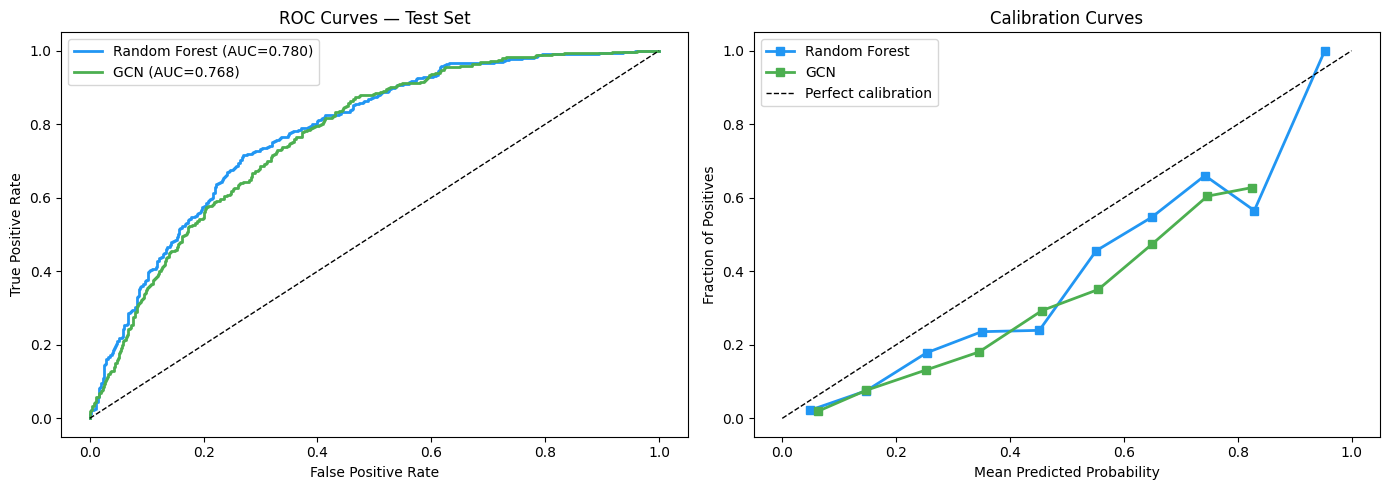

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC curves ───────────────────────────────────────────────────────────────
ax = axes[0]
for name, probs, color in [
    ('Random Forest', rf_probs_test,  '#2196F3'),
    ('GCN',           gnn_probs_test, '#4CAF50'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Test Set')
ax.legend()

# ── Calibration curves ───────────────────────────────────────────────────────
ax = axes[1]
for name, probs, color in [
    ('Random Forest', rf_probs_test,  '#2196F3'),
    ('GCN',           gnn_probs_test, '#4CAF50'),
]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, 's-', color=color, lw=2, label=name)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend()

plt.tight_layout()
plt.savefig('results_roc_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Analysis

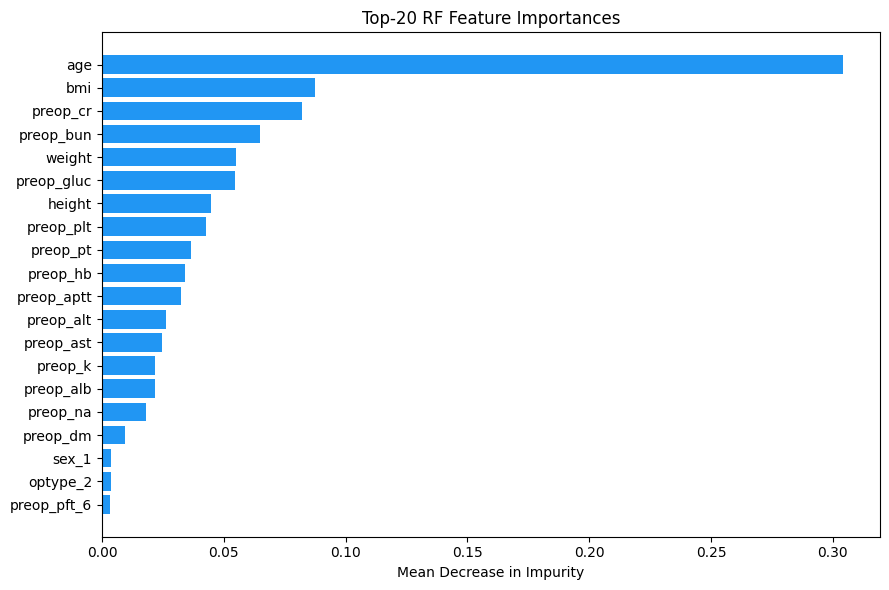

   feature  importance
       age    0.304120
       bmi    0.087235
  preop_cr    0.082009
 preop_bun    0.065023
    weight    0.054822
preop_gluc    0.054561
    height    0.044820
 preop_plt    0.042551
  preop_pt    0.036461
  preop_hb    0.034177


In [52]:
# ── RF Feature Importance ─────────────────────────────────────────────────────
# Get feature names after preprocessing
num_names = numeric_cols
try:
    ohe = preprocessor.named_transformers_['cat']['onehot']
    cat_names = list(ohe.get_feature_names_out(cat_cols))
except Exception:
    cat_names = cat_cols

feature_names = num_names + cat_names

importances = rf_model.feature_importances_
# Truncate / pad if lengths don't match (can happen with one-hot)
n = min(len(importances), len(feature_names))
imp_df = pd.DataFrame({'feature': feature_names[:n], 'importance': importances[:n]})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#2196F3')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Top-20 RF Feature Importances')
plt.tight_layout()
plt.savefig('results_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(imp_df.head(10).to_string(index=False))

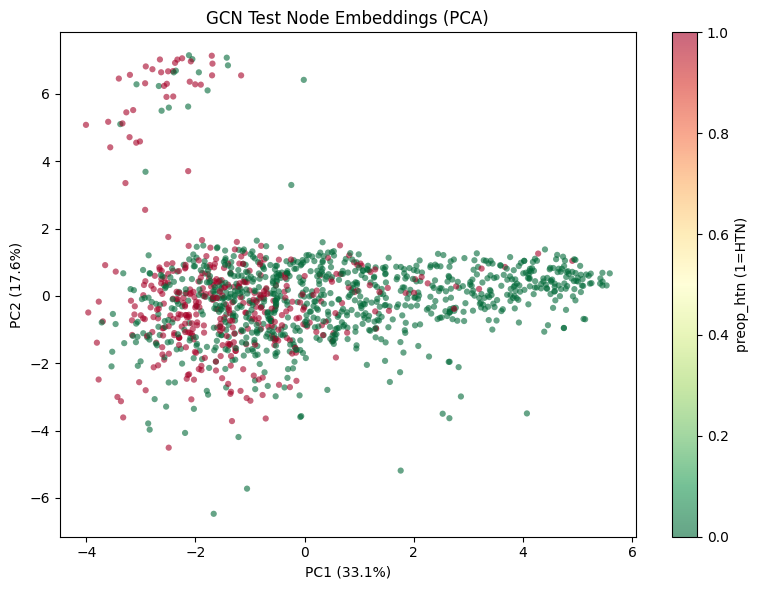

In [53]:
# ── GNN Node Embedding Visualisation (PCA) ───────────────────────────────────
from sklearn.decomposition import PCA

gnn.eval()
with torch.no_grad():
    embeddings = gnn.embed(X_full_t, adj_full_t).cpu().numpy()

# Test node embeddings only
test_embeds = embeddings[N_train:]

pca = PCA(n_components=2, random_state=SEED)
test_pca = pca.fit_transform(test_embeds)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(test_pca[:, 0], test_pca[:, 1],
                     c=y_test, cmap='RdYlGn_r', alpha=0.6, s=20, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='preop_htn (1=HTN)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('GCN Test Node Embeddings (PCA)')
plt.tight_layout()
plt.savefig('results_gnn_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

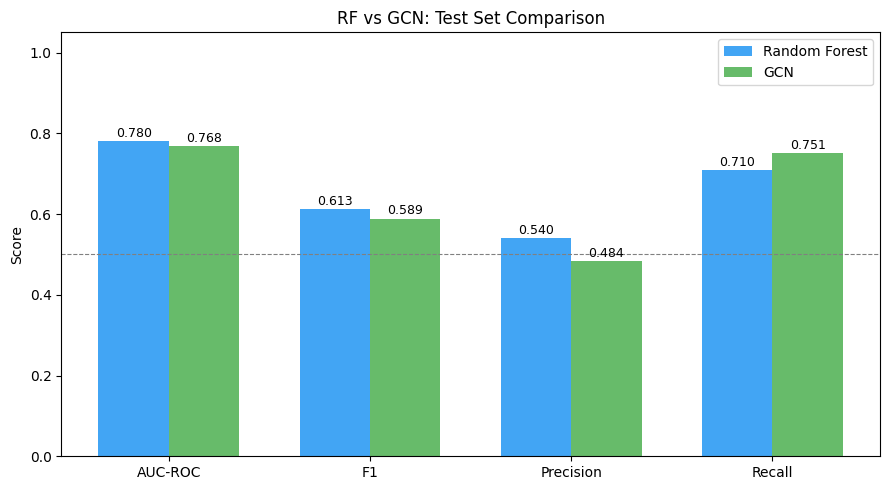

In [54]:
# ── Comparative metric bar chart ─────────────────────────────────────────────
metrics_plot = ['AUC-ROC', 'F1', 'Precision', 'Recall']
rf_vals  = [rf_metrics[m]  for m in metrics_plot]
gnn_vals = [gnn_metrics[m] for m in metrics_plot]

x = np.arange(len(metrics_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, gnn_vals, width, label='GCN',           color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('RF vs GCN: Test Set Comparison')
ax.legend()
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Random baseline')

for i, (rv, gv) in enumerate(zip(rf_vals, gnn_vals)):
    ax.text(i - width/2, rv + 0.01, f'{rv:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, gv + 0.01, f'{gv:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Results Summary

*(This cell will auto-populate once cells above are run.)*

In [55]:
delta = {k: gnn_metrics[k] - rf_metrics[k] for k in rf_metrics}

print('=' * 60)
print('EXPERIMENTAL REPORT — preop_htn Prediction (VitalDB)')
print('=' * 60)
print()
print('1. EXPERIMENTAL DESIGN')
print(f'   N={len(y_all)} patients | Target prevalence: {y_all.mean():.1%}')
print(f'   Train/Test: 80/20 stratified split')
print(f'   GNN graph: KNN (k={K_NEIGHBOURS}), cosine similarity, inductive')
print()
print('2. TEST SET PERFORMANCE')
print(results_df.to_string())
print()
print('3. DELTA GCN - RF')
for k, v in delta.items():
    direction = '▲' if v > 0 else '▼'
    print(f'   {k:12s}: {direction} {abs(v):.4f}')
print()
print('4. INTERPRETATION')
winner = 'GCN' if gnn_metrics['AUC-ROC'] > rf_metrics['AUC-ROC'] else 'Random Forest'
print(f'   Best AUC-ROC model: {winner}')
if delta['AUC-ROC'] > 0.01:
    print('   Graph-based relational modeling ADDS value for HTN prediction.')
elif delta['AUC-ROC'] < -0.01:
    print('   RF outperforms GCN — tabular features sufficient; graph adds noise.')
else:
    print('   Performance is comparable — graph provides marginal gain/loss.')
print()
print('5. LIMITATIONS')
print('   - Dense adj matrix: O(N^2) memory limits scalability to ~10k patients')
print('   - GCN trained with full train graph (not mini-batch) — may not scale')
print('   - Blood gas features dropped due to >60% missingness')
print('   - Single random seed; results should be aggregated across seeds')
print('   - ECG categorical labels may partially encode HTN (LVH) — borderline leakage')
print('=' * 60)

EXPERIMENTAL REPORT — preop_htn Prediction (VitalDB)

1. EXPERIMENTAL DESIGN
   N=6388 patients | Target prevalence: 30.8%
   Train/Test: 80/20 stratified split
   GNN graph: KNN (k=10), cosine similarity, inductive

2. TEST SET PERFORMANCE
               AUC-ROC      F1  Precision  Recall   Brier
Random Forest   0.7804  0.6132     0.5397  0.7099  0.1823
GCN             0.7681  0.5888     0.4844  0.7506  0.1964

3. DELTA GCN - RF
   AUC-ROC     : ▼ 0.0123
   F1          : ▼ 0.0244
   Precision   : ▼ 0.0553
   Recall      : ▲ 0.0407
   Brier       : ▲ 0.0141

4. INTERPRETATION
   Best AUC-ROC model: Random Forest
   RF outperforms GCN — tabular features sufficient; graph adds noise.

5. LIMITATIONS
   - Dense adj matrix: O(N^2) memory limits scalability to ~10k patients
   - GCN trained with full train graph (not mini-batch) — may not scale
   - Blood gas features dropped due to >60% missingness
   - Single random seed; results should be aggregated across seeds
   - ECG categorical labe